In [1]:
%pip install tqdm
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Step 1: Imports and Device Setup
- First, fetch the necessary deep learning packages and configure the script to run on your GPU if you have one available

In [1]:
import torch
import torchvision

print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)
print("Is GPU available on Jubail?:", torch.cuda.is_available())

PyTorch Version: 2.2.2+cu118
Torchvision Version: 0.17.2+cu118
Is GPU available on Jubail?: True


In [2]:
# 1. import and device setup
import torch
import torch.nn as nn
import torch. optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import copy

In [3]:
# ==========================================
# 1. Configuration 
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

EPOCHS_BASE = 200
EPOCHS_RETAIN = 200
BATCH_SIZE = 128
LR = 0.01
CHECKPOINT_INTERVAL = 40  # Save model state every 40 epochs for TracIn

Using device: cuda


## Step 2: Data Preprocessing and Loaders
- CIFAR-10 has 10 classes. We will apply random cropping and horizontal flipping as data augmentation to prevent overfitting, followed by standard normalization

In [4]:
# ==========================================
# 2. Data Loading
# ==========================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
all_indices = np.arange(len(trainset))

Files already downloaded and verified
Files already downloaded and verified


## 3. Modifying ResNet-18 for CIFAR-10
- Instead of writing 18 layers from scratch, we can load PyTorch's native resnet17. however, the standard version starts with a 7x7 convolution and max pooling, which reduces a 32 x 32 image down to 4x4 instantly.
- To fix this, swap the first layer to a 3 x 3 convolution, remove the max pool and match the final fully connected layer (fc) to output 10 classes

In [5]:
# ==========================================
# 3. Utilities
# ==========================================
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

def get_resnet18():
    model = torchvision.models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(DEVICE)

def evaluate_model(model, dataloader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

In [7]:
# ==========================================
# 3. Model Definition (ResNet-18) REMOVE????????
# ==========================================
# def get_resnet18():
#     # Load an untrained ResNet18
#     model = torchvision.models.resnet18(weights=None)
    
#     # 1. Adapt the first convolutional layer for 32x32 images
#     model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    
#     # 2. Bypass the max pooling layer 
#     model.maxpool = nn.Identity()
    
#     # 3. Modify the final layer for 10 classes (CIFAR-10)
#     model.fc = nn.Linear(model.fc.in_features, 10)
    
#     return model.to(DEVICE)

## 4. Loss Function and Optimizer
- We will use Cross-Entropy Loss and Stochastic Gradient Descent (SGD) with momentum, which historically performs exceptionally well on CIFAR-10

In [6]:
# ==========================================
# 4. Base Training with Checkpointing
# ==========================================
set_seed(42)
base_model = get_resnet18()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(base_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_BASE)

trainloader_base = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

saved_checkpoints = []

print("--- Starting Base Model Training ---")
base_model.train()
for epoch in range(EPOCHS_BASE):
    running_loss = 0.0
    for inputs, targets in trainloader_base:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = base_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    scheduler.step()
    
    # Save checkpoints for TracIn
    if (epoch + 1) % CHECKPOINT_INTERVAL == 0:
        saved_checkpoints.append(copy.deepcopy(base_model.state_dict()))
        
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_BASE} | Loss: {running_loss/len(trainloader_base):.4f}")

base_acc = evaluate_model(base_model, testloader)
print(f"\nBase Model Final Accuracy: {base_acc:.2f}%")

--- Starting Base Model Training ---


/scratch/ss17886/conda/envs/deeplearning/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch 20/200 | Loss: 0.2167
Epoch 40/200 | Loss: 0.0919
Epoch 60/200 | Loss: 0.0482
Epoch 80/200 | Loss: 0.0345
Epoch 100/200 | Loss: 0.0144
Epoch 120/200 | Loss: 0.0055
Epoch 140/200 | Loss: 0.0015
Epoch 160/200 | Loss: 0.0011
Epoch 180/200 | Loss: 0.0011
Epoch 200/200 | Loss: 0.0011

Base Model Final Accuracy: 93.83%


In [8]:
# ==========================================
# 5. Compute TracIn Influence Scores
# ==========================================
print("\n--- Computing TracIn Influence Scores ---")
eval_loader = DataLoader(trainset, batch_size=1, shuffle=False)
influence_scores = {i: 0.0 for i in range(len(trainset))}

# Load each checkpoint to measure historical gradients
for cp_idx, state_dict in enumerate(saved_checkpoints):
    print(f"Processing Checkpoint {cp_idx + 1}/{len(saved_checkpoints)}...")
    temp_model = get_resnet18()
    temp_model.load_state_dict(state_dict)
    temp_model.eval()
    
    for i, (inputs, targets) in enumerate(eval_loader):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        temp_model.zero_grad()
        outputs = temp_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        
        grad_norm = 0.0
        for param in temp_model.fc.parameters():
            if param.grad is not None:
                grad_norm += param.grad.data.norm(2).item() ** 2
                
        influence_scores[i] += grad_norm

# Sort by total accumulated influence
influence_ranking = sorted(influence_scores.items(), key=lambda x: x[1], reverse=True)
top_global_indices = [x[0] for x in influence_ranking]
print("Influence computation complete.")


--- Computing TracIn Influence Scores ---
Processing Checkpoint 1/5...
Processing Checkpoint 2/5...
Processing Checkpoint 3/5...
Processing Checkpoint 4/5...
Processing Checkpoint 5/5...
Influence computation complete.


In [10]:
# ==========================================
# 4. Training and Evaluation Functions - REMOEV????????
# ==========================================
# def train_model(model, dataloader, epochs, title="Training"):
#     criterion = nn.CrossEntropyLoss()
#     optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
#     scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
#     model.train()
#     for epoch in range(epochs):
#         running_loss = 0.0
#         for inputs, targets in dataloader:
#             inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            
#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = criterion(outputs, targets)
#             loss.backward()
#             optimizer.step()
            
#             running_loss += loss.item()
#         scheduler.step()
#         if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
#             print(f"[{title}] Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(dataloader):.4f}")
#     return model

# def evaluate_model(model, dataloader):
#     model.eval()
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for inputs, targets in dataloader:
#             inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
#             outputs = model(inputs)
#             _, predicted = outputs.max(1)
#             total += targets.size(0)
#             correct += predicted.eq(targets).sum().item()
#     return 100. * correct / total

## 5. Training Loop
- This function runs through the dataset, calculates the loss, performs backpropagation, and updates the weights

In [11]:
# # ==========================================
# # 5. First-Order Influence Approximation
# # ==========================================
# def compute_influence_scores(model, train_dataset):
#     """
#     Estimates the influence of each training sample.
#     Uses the magnitude of the loss gradient with respect to model parameters 
#     as a fast proxy for self-influence.
#     """
#     print("Computing influence scores (First-Order Approximation)...")
#     model.eval()
#     criterion = nn.CrossEntropyLoss()
    
#     # Use a dataloader with batch_size=1 to get individual gradients
#     # Note: This is sequential and can be slow. 
#     eval_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)
    
#     influence_scores = []
    
#     for i, (inputs, targets) in enumerate(eval_loader):
#         inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
#         model.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, targets)
#         loss.backward()
        
#         # Calculate the L2 norm of the gradients of the last fully connected layer
#         # as a proxy for the sample's influence/memorization factor
#         grad_norm = 0.0
#         for param in model.fc.parameters():
#             if param.grad is not None:
#                 grad_norm += param.grad.data.norm(2).item() ** 2
                
#         influence_scores.append((i, grad_norm))
        
#         if (i + 1) % 10000 == 0:
#             print(f"Processed {i + 1}/{len(train_dataset)} samples.")
            
#     # Sort by influence score (descending)
#     influence_scores.sort(key=lambda x: x[1], reverse=True)
#     return influence_scores

## 6. Testing Loop
- After each training epoch, evaluate the model on unseen test images to track performance accuracy

In [12]:
# # ==========================================
# # 6. Main Experiment Pipeline
# # ==========================================
# print("\n--- Starting Baseline Training ---")
# base_model = get_resnet18()
# base_model = train_model(base_model, trainloader, EPOCHS_BASE, title="Base Model")
# base_acc = evaluate_model(base_model, testloader)
# print(f"Base Model Accuracy: {base_acc:.2f}%\n")

# # Compute Influence
# influence_ranking = compute_influence_scores(base_model, trainset)
# top_influence_indices = [x[0] for x in influence_ranking]

# # Store results for plotting
# results = {
#     "k_values": K_VALUES,
#     "top_influence_acc": [],
#     "random_acc": []
# }

# all_indices = np.arange(len(trainset))

# for k in K_VALUES:
#     print(f"\n================ Running for K = {k} ================")
    
#     # 1. Remove Top-K Influential Images
#     indices_to_keep_top = list(set(all_indices) - set(top_influence_indices[:k]))
#     subset_top = Subset(trainset, indices_to_keep_top)
#     loader_top = DataLoader(subset_top, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    
#     print(f"Training model without Top {k} influential images...")
#     model_top = get_resnet18()
#     model_top = train_model(model_top, loader_top, EPOCHS_RETAIN, title=f"Top-{k} Removed")
#     acc_top = evaluate_model(model_top, testloader)
#     results["top_influence_acc"].append(acc_top)
#     print(f"Accuracy without Top {k}: {acc_top:.2f}%")
    
#     # 2. Remove Random-K Images
#     random_indices_to_remove = np.random.choice(all_indices, k, replace=False)
#     indices_to_keep_random = list(set(all_indices) - set(random_indices_to_remove))
#     subset_random = Subset(trainset, indices_to_keep_random)
#     loader_random = DataLoader(subset_random, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    
#     print(f"Training model without Random {k} images...")
#     model_random = get_resnet18()
#     model_random = train_model(model_random, loader_random, EPOCHS_RETAIN, title=f"Random-{k} Removed")
#     acc_random = evaluate_model(model_random, testloader)
#     results["random_acc"].append(acc_random)
#     print(f"Accuracy without Random {k}: {acc_random:.2f}%")

--- Starting Global Removal Experiment ---

================ Evaluating K = 500 ================

  Running Seed 42...
    -> Training Top-500 Removed Model...
       [Top-500] Epoch 1/200 | Loss: 1.5438
       [Top-500] Epoch 20/200 | Loss: 0.2091
       [Top-500] Epoch 40/200 | Loss: 0.0879
       [Top-500] Epoch 60/200 | Loss: 0.0551
       [Top-500] Epoch 80/200 | Loss: 0.0290
       [Top-500] Epoch 100/200 | Loss: 0.0166
       [Top-500] Epoch 120/200 | Loss: 0.0047
       [Top-500] Epoch 140/200 | Loss: 0.0013
       [Top-500] Epoch 160/200 | Loss: 0.0012
       [Top-500] Epoch 180/200 | Loss: 0.0011
       [Top-500] Epoch 200/200 | Loss: 0.0011
    -> Top-500 Model Accuracy: 93.99%
    -> Training Random-500 Removed Model...
       [Rand-500] Epoch 1/200 | Loss: 1.5607
       [Rand-500] Epoch 20/200 | Loss: 0.2171
       [Rand-500] Epoch 40/200 | Loss: 0.0907
       [Rand-500] Epoch 60/200 | Loss: 0.0522
       [Rand-500] Epoch 80/200 | Loss: 0.0309
       [Rand-500] Epoch 100/2

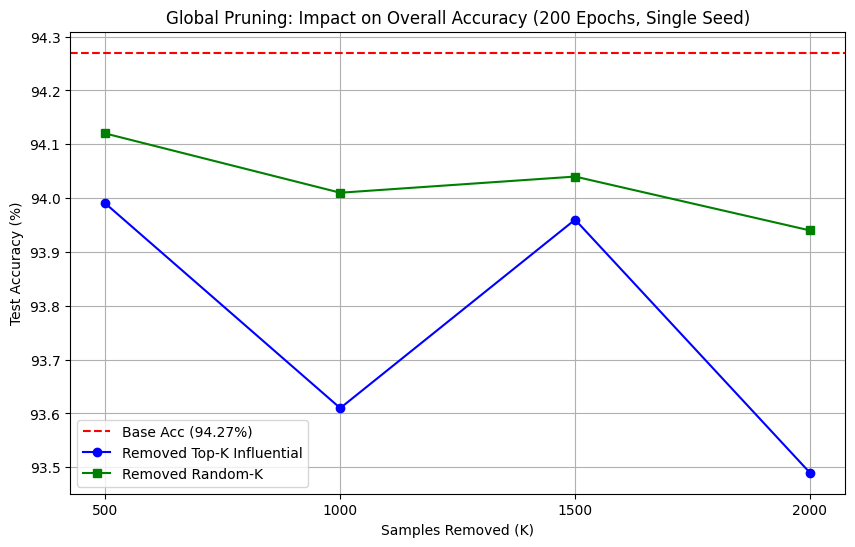

In [9]:
# ==========================================
# 6. Global K-Removal Experiment (Single Seed)
# ==========================================
SEEDS = [42]  # Reduced to a single seed for speed
K_VALUES = [500, 1000, 1500, 2000]

global_results = {
    "k_values": K_VALUES,
    "top_acc": {k: [] for k in K_VALUES},
    "rand_acc": {k: [] for k in K_VALUES}
}

print("--- Starting Global Removal Experiment ---")

for k in K_VALUES:
    print(f"\n================ Evaluating K = {k} ================")
    
    # Pre-calculate indices to keep for TOP-K
    indices_keep_top = list(set(all_indices) - set(top_global_indices[:k]))
    subset_top = Subset(trainset, indices_keep_top)
    
    for seed in SEEDS:
        set_seed(seed)
        print(f"\n  Running Seed {seed}...")
        
        # -----------------------------------------
        # 1. Top-K Training
        # -----------------------------------------
        print(f"    -> Training Top-{k} Removed Model...")
        loader_top = DataLoader(subset_top, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        model_top = get_resnet18()
        optimizer = optim.SGD(model_top.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_RETAIN)
        
        model_top.train()
        for epoch in range(EPOCHS_RETAIN):
            running_loss = 0.0
            for inputs, targets in loader_top:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                optimizer.zero_grad()
                loss = nn.CrossEntropyLoss()(model_top(inputs), targets)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            scheduler.step()
            
            # Print progress every 20 epochs
            if (epoch + 1) % 20 == 0 or epoch == 0:
                print(f"       [Top-{k}] Epoch {epoch+1}/{EPOCHS_RETAIN} | Loss: {running_loss/len(loader_top):.4f}")
                
        top_acc = evaluate_model(model_top, testloader)
        global_results["top_acc"][k].append(top_acc)
        print(f"    -> Top-{k} Model Accuracy: {top_acc:.2f}%")
        
        # -----------------------------------------
        # 2. Random-K Training
        # -----------------------------------------
        print(f"    -> Training Random-{k} Removed Model...")
        random_remove = np.random.choice(all_indices, k, replace=False)
        indices_keep_rand = list(set(all_indices) - set(random_remove))
        subset_rand = Subset(trainset, indices_keep_rand)
        loader_rand = DataLoader(subset_rand, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        
        model_rand = get_resnet18()
        optimizer = optim.SGD(model_rand.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_RETAIN)
        
        model_rand.train()
        for epoch in range(EPOCHS_RETAIN):
            running_loss = 0.0
            for inputs, targets in loader_rand:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                optimizer.zero_grad()
                loss = nn.CrossEntropyLoss()(model_rand(inputs), targets)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            scheduler.step()
            
            # Print progress every 20 epochs
            if (epoch + 1) % 20 == 0 or epoch == 0:
                print(f"       [Rand-{k}] Epoch {epoch+1}/{EPOCHS_RETAIN} | Loss: {running_loss/len(loader_rand):.4f}")
                
        rand_acc = evaluate_model(model_rand, testloader)
        global_results["rand_acc"][k].append(rand_acc)
        print(f"    -> Random-{k} Model Accuracy: {rand_acc:.2f}%")

# Aggregate and Plot
avg_top = [np.mean(global_results["top_acc"][k]) for k in K_VALUES]
avg_rand = [np.mean(global_results["rand_acc"][k]) for k in K_VALUES]

plt.figure(figsize=(10, 6))
plt.axhline(y=base_acc, color='r', linestyle='--', label=f'Base Acc ({base_acc:.2f}%)')
plt.plot(K_VALUES, avg_top, marker='o', color='b', label='Removed Top-K Influential')
plt.plot(K_VALUES, avg_rand, marker='s', color='g', label='Removed Random-K')
plt.title('Global Pruning: Impact on Overall Accuracy (200 Epochs, Single Seed)')
plt.xlabel('Samples Removed (K)')
plt.ylabel('Test Accuracy (%)')
plt.xticks(K_VALUES)
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# ==========================================
# 7. Class-Specific Experiment (Single Seed)
# ==========================================
SEEDS = [42]  # Reduced to a single seed for speed
TARGET_CLASS = 3  # Class 3 is 'cat' in CIFAR-10
CLASS_K_VALUES = [100, 250, 500, 1000] 

# Isolate target class
class_indices = [i for i, label in enumerate(trainset.targets) if label == TARGET_CLASS]
class_influence = [item for item in influence_ranking if item[0] in class_indices]
top_class_indices = [x[0] for x in class_influence]

class_results = {
    "k_values": CLASS_K_VALUES,
    "top_acc": {k: [] for k in CLASS_K_VALUES},
    "rand_acc": {k: [] for k in CLASS_K_VALUES}
}

print(f"--- Starting Class {TARGET_CLASS} Removal Experiment ---")

for k in CLASS_K_VALUES:
    print(f"\n================ Evaluating Class {TARGET_CLASS}, K = {k} ================")
    
    indices_keep_top = list(set(all_indices) - set(top_class_indices[:k]))
    subset_top = Subset(trainset, indices_keep_top)
    
    for seed in SEEDS:  # SEEDS is now just [42]
        set_seed(seed)
        print(f"\n  Running Seed {seed}...")
        
        # -----------------------------------------
        # 1. Top-K Class Training
        # -----------------------------------------
        print(f"    -> Training Class {TARGET_CLASS} Top-{k} Removed Model...")
        loader_top = DataLoader(subset_top, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        model_top = get_resnet18()
        optimizer = optim.SGD(model_top.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_RETAIN)
        
        model_top.train()
        for epoch in range(EPOCHS_RETAIN):
            running_loss = 0.0
            for inputs, targets in loader_top:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                optimizer.zero_grad()
                loss = nn.CrossEntropyLoss()(model_top(inputs), targets)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            scheduler.step()
            
            if (epoch + 1) % 20 == 0 or epoch == 0:
                print(f"       [Class {TARGET_CLASS} Top-{k}] Epoch {epoch+1}/{EPOCHS_RETAIN} | Loss: {running_loss/len(loader_top):.4f}")
                
        top_acc = evaluate_model(model_top, testloader)
        class_results["top_acc"][k].append(top_acc)
        print(f"    -> Class {TARGET_CLASS} Top-{k} Model Accuracy: {top_acc:.2f}%")
        
        # -----------------------------------------
        # 2. Random-K Class Training
        # -----------------------------------------
        print(f"    -> Training Class {TARGET_CLASS} Random-{k} Removed Model...")
        random_remove = np.random.choice(class_indices, k, replace=False)
        indices_keep_rand = list(set(all_indices) - set(random_remove))
        subset_rand = Subset(trainset, indices_keep_rand)
        loader_rand = DataLoader(subset_rand, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        
        model_rand = get_resnet18()
        optimizer = optim.SGD(model_rand.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_RETAIN)
        
        model_rand.train()
        for epoch in range(EPOCHS_RETAIN):
            running_loss = 0.0
            for inputs, targets in loader_rand:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                optimizer.zero_grad()
                loss = nn.CrossEntropyLoss()(model_rand(inputs), targets)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            scheduler.step()
            
            if (epoch + 1) % 20 == 0 or epoch == 0:
                print(f"       [Class {TARGET_CLASS} Rand-{k}] Epoch {epoch+1}/{EPOCHS_RETAIN} | Loss: {running_loss/len(loader_rand):.4f}")
                
        rand_acc = evaluate_model(model_rand, testloader)
        class_results["rand_acc"][k].append(rand_acc)
        print(f"    -> Class {TARGET_CLASS} Random-{k} Model Accuracy: {rand_acc:.2f}%")

# Aggregate and Plot
avg_class_top = [np.mean(class_results["top_acc"][k]) for k in CLASS_K_VALUES]
avg_class_rand = [np.mean(class_results["rand_acc"][k]) for k in CLASS_K_VALUES]

plt.figure(figsize=(10, 6))
plt.axhline(y=base_acc, color='r', linestyle='--', label=f'Base Acc ({base_acc:.2f}%)')
plt.plot(CLASS_K_VALUES, avg_class_top, marker='o', color='b', label=f'Removed Top-K (Class {TARGET_CLASS})')
plt.plot(CLASS_K_VALUES, avg_class_rand, marker='s', color='g', label=f'Removed Random-K (Class {TARGET_CLASS})')
plt.title(f'Class {TARGET_CLASS} Pruning: Impact on Overall Accuracy (200 Epochs, Single Seed)')
plt.xlabel(f'Class {TARGET_CLASS} Samples Removed')
plt.ylabel('Test Accuracy (%)')
plt.xticks(CLASS_K_VALUES)
plt.legend()
plt.grid(True)
plt.show()

--- Starting Class 3 Removal Experiment ---

================ Evaluating Class 3, K = 100 ================

  Running Seed 42...
    -> Training Class 3 Top-100 Removed Model...
       [Class 3 Top-100] Epoch 1/200 | Loss: 1.5706
       [Class 3 Top-100] Epoch 20/200 | Loss: 0.2153
       [Class 3 Top-100] Epoch 40/200 | Loss: 0.0897
       [Class 3 Top-100] Epoch 60/200 | Loss: 0.0475
       [Class 3 Top-100] Epoch 80/200 | Loss: 0.0300


KeyboardInterrupt: 

## 7. Run the Training
- Let's tie it all together and run it for 30 epochs

In [12]:
import torch
import os

print("=== Hardware Diagnostic ===")

# Check CPU Cores
print(f"Available CPU Cores: {os.cpu_count()}")

# Check GPU
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    
    # Check GPU Memory (VRAM)
    allocated = torch.cuda.memory_allocated(0) / 1024**3
    reserved = torch.cuda.memory_reserved(0) / 1024**3
    print(f"VRAM Allocated: {allocated:.2f} GB")
    print(f"VRAM Reserved:  {reserved:.2f} GB")
else:
    print("CUDA is NOT available! You are running on the CPU.")

=== Hardware Diagnostic ===
Available CPU Cores: 128
GPU Model: NVIDIA A100-PCIE-40GB
VRAM Allocated: 0.53 GB
VRAM Reserved:  1.20 GB
